# Adatbázis EXIF statisztikák

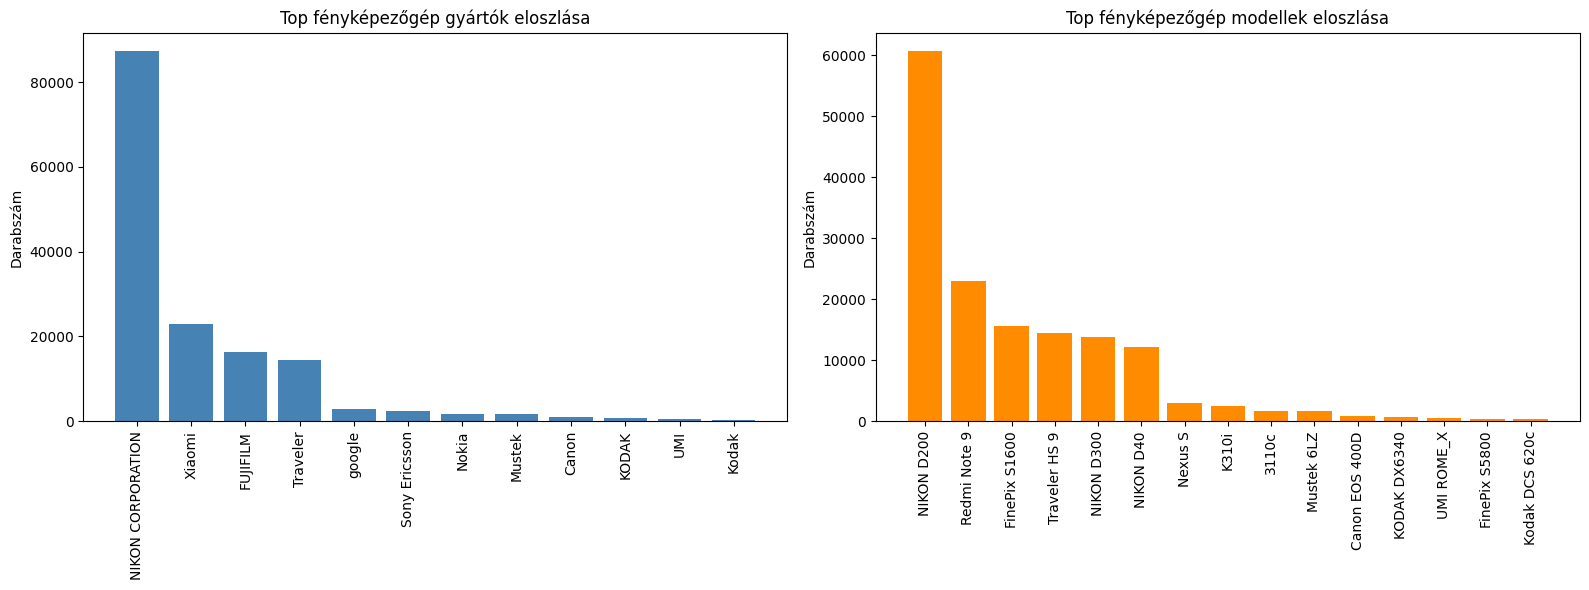

,Tulajdonság,Érték
0,Fájlok száma,180750
1,Összes fájlméret (MB),9672.07
2,Átlagos fájlméret (MB),0.05
3,Fájltípus,.jpg


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Méret átszámítás MB-ba, és táblázat készítése
files_count = 180750
total_size_bytes = 10141899093
average_size_bytes = 56109.78

total_size_mb = total_size_bytes / (1024 * 1024)
average_size_mb = average_size_bytes / (1024 * 1024)

file_stats_df = pd.DataFrame({
    "Tulajdonság": ["Fájlok száma", "Összes fájlméret (MB)", "Átlagos fájlméret (MB)", "Fájltípus"],
    "Érték": [files_count, round(total_size_mb, 2), round(average_size_mb, 2), ".jpg"]
})

# 2. Gyártó statisztika feldolgozása
manufacturer_data = {
    "NIKON CORPORATION": 87242,
    "Xiaomi": 22979,
    "FUJIFILM": 16451,
    "Traveler": 14532,
    "google": 2925,
    "Sony Ericsson": 2459,
    "Nokia": 1782,
    "Mustek": 1611,
    "Canon": 1114,
    "KODAK": 783,
    "UMI": 487,
    "Kodak": 362,
    "LG Electronics": 245,
    "SAMSUNG": 210,
    "HUAWEI": 176,
    "NIKON": 176,
    "SONY": 132,
    "Sony": 128,
    "Panasonic": 98,
    "OLYMPUS IMAGING CORP.": 44,
    "Apple": 33,
    "Noname": 8,
    "Hyundai": 6,
    "Samsung Techwin": 3,
    "228_216": 1,
    "Hewlett-Packard": 1,
    "OLYMPUS CORPORATION": 1,
    "OLYMPUS OPTICAL CO LTD": 1
}

# Kategóriák szétválasztása
manufacturer_df = pd.DataFrame(list(manufacturer_data.items()), columns=["Gyártó", "Darabszám"])
manufacturer_df['Kategória'] = manufacturer_df['Darabszám'].apply(lambda x: 'Egyéb' if x < 300 else 'Top gyártók')

# Csoportosítás a megjelenítéshez
grouped_manufacturers = manufacturer_df.groupby(['Kategória', 'Gyártó']).sum().reset_index()
aggregated_manufacturers = grouped_manufacturers.groupby('Gyártó').sum().reset_index()

# Pie chart készítés
top_vs_other = manufacturer_df.groupby('Kategória')['Darabszám'].sum().reset_index()
top_manufacturers = manufacturer_df[manufacturer_df['Kategória'] == 'Top gyártók']

# 3. Modell statisztika feldolgozása
model_data = {
    "NIKON D200": 60663, "Redmi Note 9": 22979, "FinePix S1600": 15689, "Traveler HS 9": 14532,
    "NIKON D300": 13833, "NIKON D40": 12248, "Nexus S": 2925, "K310i": 2427, "3110c": 1763,
    "Mustek 6LZ": 1611, "Canon EOS 400D": 882, "KODAK DX6340": 782, "UMI ROME_X": 487,
    "FinePix S5800": 376, "Kodak DCS 620c": 360, "NIKON D100": 257, "M3510": 192, "U8815": 176,
    "NIKON D7100": 176, "LG-P710": 151, "COOLPIX L11": 146, "H3113": 128, "FinePix S9600": 114,
    "FinePix S304": 103, "FinePix S8000fd": 98, "Canon PowerShot A70": 95, "LGP500": 94,
    "DSC-T700": 91, "Canon PowerShot S5 IS": 71, "DMC-FZ45": 69, "FinePix S1000fd": 40,
    "NIKON D70s": 37, "iPhone 13": 33, "Canon PowerShot A590 IS": 30, "COOLPIX L10": 29,
    "DSC-W530": 27, "FE-120,X-700": 26, "FinePix AX200": 22, "SM-G360F": 18, "6120c": 17,
    "FE47,X43": 13, "W200i": 13, "DSC-P41": 12, "NIKON D90": 12, "DMC-LS60": 12, "DMC-FP1": 10,
    "NIKON D80": 9, "Z530i": 8, "DV": 8, "A9325": 6, "W350i": 5, "Canon EOS 40D": 5, "S302": 4,
    "FinePix S5700 S700": 4, "Canon EOS 1000D": 4, "DMC-FZ28": 4, "Canon EOS 650D": 3,
    "Digimax S500 / Kenox S500 / Digimax Cyber 530": 2, "Canon EOS DIGITAL REBEL XT": 2,
    "FinePix HS10 HS11": 2, "Canon EOS 5D": 2, "SP320": 2, "Canon EOS 1100D": 2,
    "FinePix S7000": 2, "NIKON D1H": 2, "Canon EOS 350D DIGITAL": 2, "Kodak DCS Pro 14nx": 2,
    "S500i": 2, "Canon EOS 5D Mark II": 2, "Canon EOS-1Ds Mark II": 2, "Canon EOS 7D": 2,
    "u720SW,S720SW": 2, "Canon PowerShot SX100 IS": 2, "NIKON D60": 1, "NIKON D5100": 1,
    "DMC-G1": 1, "Canon PowerShot S2 IS": 1, "6234": 1, "Digimax S800 Kenox S800": 1,
    "NIKON D3X": 1, "DSC-T7": 1, "6303 classic": 1, "Canon EOS 20D": 1, "Canon EOS 550D": 1,
    "Canon EOS 300D DIGITAL": 1, "Canon EOS 10D": 1, "NIKON D70": 1, "Canon PowerShot SX10 IS": 1,
    "DMC-FZ18": 1, "Canon EOS 600D": 1, "HDR-XR520VE": 1, "VR360,D760": 1, "DV531": 1,
    "NIKON D3100": 1, "KODAK DX7590 ZOOM DIGITAL CAMERA": 1, "hp photosmart 735": 1,
    "C725UZ": 1, "C2Z,D520Z,C220Z": 1, "Canon PowerShot A95": 1, "PENTAX K-r": 1,
    "E4500": 1, "HDC-SD60": 1, "FinePix HS20EXR": 1
}

model_df = pd.DataFrame(list(model_data.items()), columns=["Modell", "Darabszám"])
model_df['Kategória'] = model_df['Darabszám'].apply(lambda x: 'Egyéb' if x < 300 else 'Top modellek')
top_models = model_df[model_df['Kategória'] == 'Top modellek']

# Modell diagramhoz csoportosítás
top_vs_other_models = model_df.groupby('Kategória')['Darabszám'].sum().reset_index()

# Grafikon készítése
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Gyártók diagram
axs[0].bar(top_manufacturers['Gyártó'], top_manufacturers['Darabszám'], color='steelblue')
axs[0].set_title('Top fényképezőgép gyártók eloszlása')
axs[0].set_ylabel('Darabszám')
axs[0].tick_params(axis='x', rotation=90)

# Modellek diagram
axs[1].bar(top_models['Modell'], top_models['Darabszám'], color='darkorange')
axs[1].set_title('Top fényképezőgép modellek eloszlása')
axs[1].set_ylabel('Darabszám')
axs[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

file_stats_df.head()


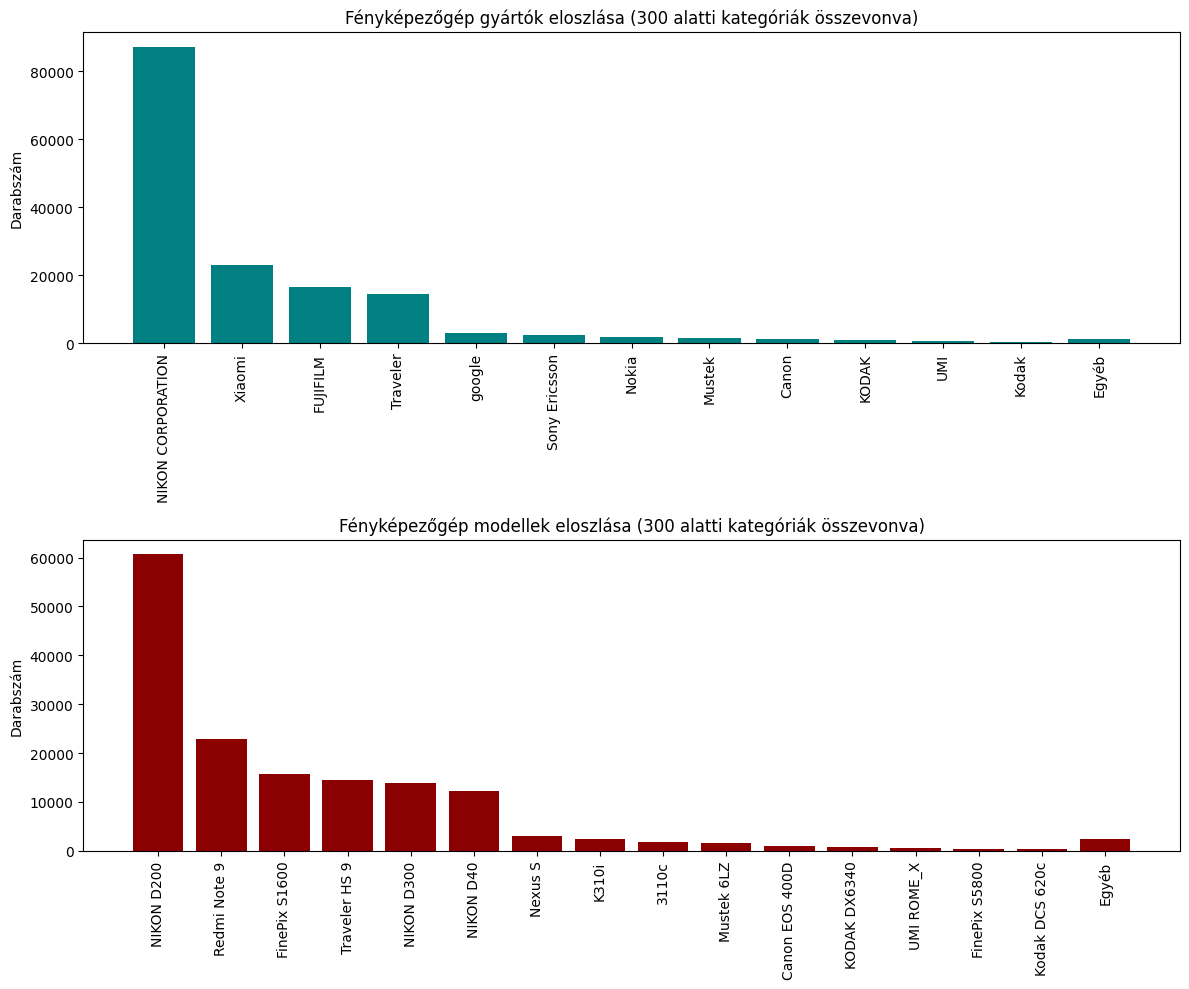

(              Gyártó  Darabszám    Kategória
 0  NIKON CORPORATION      87242  Top gyártók
 1             Xiaomi      22979  Top gyártók
 2           FUJIFILM      16451  Top gyártók
 3           Traveler      14532  Top gyártók
 4             google       2925  Top gyártók
 5      Sony Ericsson       2459  Top gyártók
 6              Nokia       1782  Top gyártók
 7             Mustek       1611  Top gyártók
 8              Egyéb       1263          NaN
 9              Canon       1114  Top gyártók,
           Modell  Darabszám     Kategória
 0     NIKON D200      60663  Top modellek
 1   Redmi Note 9      22979  Top modellek
 2  FinePix S1600      15689  Top modellek
 3  Traveler HS 9      14532  Top modellek
 4     NIKON D300      13833  Top modellek
 5      NIKON D40      12248  Top modellek
 6        Nexus S       2925  Top modellek
 7          Egyéb       2434           NaN
 8          K310i       2427  Top modellek
 9          3110c       1763  Top modellek)

In [2]:

# Modell adat újracsoportosítása
top_models_only = model_df[model_df['Darabszám'] >= 300].copy()
below_300_models_sum = model_df[model_df['Darabszám'] < 300]['Darabszám'].sum()

# Új sor létrehozása és hozzáfűzése
egyeb_model_row = pd.DataFrame([{'Modell': 'Egyéb', 'Darabszám': below_300_models_sum}])
model_df_grouped = pd.concat([top_models_only, egyeb_model_row], ignore_index=True)


# Gyártói adat újracsoportosítása
top_manufacturers_only = manufacturer_df[manufacturer_df['Darabszám'] >= 300].copy()
below_300_manufacturers_sum = manufacturer_df[manufacturer_df['Darabszám'] < 300]['Darabszám'].sum()

# Új sor létrehozása és hozzáfűzése
egyeb_manufacturer_row = pd.DataFrame([{'Gyártó': 'Egyéb', 'Darabszám': below_300_manufacturers_sum}])
manufacturer_df_grouped = pd.concat([top_manufacturers_only, egyeb_manufacturer_row], ignore_index=True)

# Külön diagramok készítése
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Gyártók diagram
ax1.bar(manufacturer_df_grouped['Gyártó'], manufacturer_df_grouped['Darabszám'], color='teal')
ax1.set_title('Fényképezőgép gyártók eloszlása (300 alatti kategóriák összevonva)')
ax1.set_ylabel('Darabszám')
ax1.tick_params(axis='x', rotation=90)

# Modellek diagram
ax2.bar(model_df_grouped['Modell'], model_df_grouped['Darabszám'], color='darkred')
ax2.set_title('Fényképezőgép modellek eloszlása (300 alatti kategóriák összevonva)')
ax2.set_ylabel('Darabszám')
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# Kimeneti táblázatok megjelenítése
manufacturer_df_grouped_table = manufacturer_df_grouped.sort_values(by="Darabszám", ascending=False).reset_index(drop=True)
model_df_grouped_table = model_df_grouped.sort_values(by="Darabszám", ascending=False).reset_index(drop=True)

manufacturer_df_grouped_table.head(10), model_df_grouped_table.head(10)


    ISO_kategória  Darabszám
1             100      37670
5             400      33242
2             200      26917
8             800      15706
6             500       9906
0              50       7435
11           1600       2982
3             250       2238
7             640       1690
4             320       1382
9            1000       1098
14           3200        797
10           1250        585
12           2000        439
13           2500        178


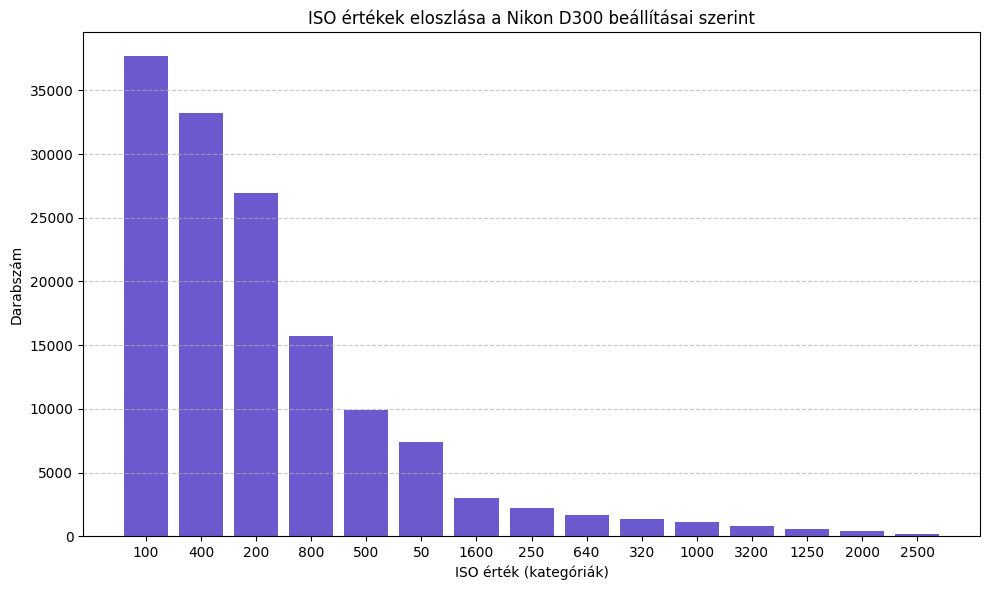

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Nikon D300 beállítható ISO értékek (manuál és 1/3 lépésköz szerint)
nikon_d300_iso_steps = [50, 100, 200, 250, 320, 400, 500, 640, 800, 1000, 1250, 1600, 2000, 2500, 3200]

# ISO adat beolvasása
iso_df = pd.read_csv("EXIF_ISO.csv")

# ISO oszlop biztosítása numerikus típusra (hibás értékeket NaN-ra állítja)
iso_df['ISO'] = pd.to_numeric(iso_df['ISO'], errors='coerce')
iso_df['Darabszám'] = pd.to_numeric(iso_df['Darabszám'], errors='coerce')

# Érvénytelen sorok eltávolítása (ahol bármelyik érték hiányzik)
iso_df = iso_df.dropna(subset=['ISO', 'Darabszám'])

# ISO érték legközelebbi Nikon kategóriába sorolása
def closest_iso(value):
    return min(nikon_d300_iso_steps, key=lambda x: abs(x - value))

iso_df['ISO_kategória'] = iso_df['ISO'].apply(closest_iso)


# Feltételezzük, hogy a fájl oszlopai: 'ISO', 'Darabszám'
# A legközelebbi Nikon ISO érték megtalálása
def closest_iso(value):
    return min(nikon_d300_iso_steps, key=lambda x: abs(x - value))

# Új oszlop: Nikon D300 kategóriába sorolva
iso_df['ISO_kategória'] = iso_df['ISO'].apply(closest_iso)

# Csoportosítás és összegzés
# grouped_iso = iso_df.groupby('ISO_kategória')['Darabszám'].sum().reset_index().sort_values('ISO_kategória')
grouped_iso = iso_df.groupby('ISO_kategória')['Darabszám'].sum().reset_index().sort_values('Darabszám', ascending=False)

# Táblázat kiírása
print(grouped_iso)

# Diagram készítése
plt.figure(figsize=(10, 6))
plt.bar(grouped_iso['ISO_kategória'].astype(str), grouped_iso['Darabszám'], color='slateblue')
plt.title('ISO értékek eloszlása a Nikon D300 beállításai szerint')
plt.xlabel('ISO érték (kategóriák)')
plt.ylabel('Darabszám')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


    Záridő_kategória  Darabszám
20          0.012500      14364
19          0.010000      13498
18          0.008000      11103
21          0.016667      10894
22          0.020000       6286
24          0.033333       5880
14          0.003125       5534
15          0.004000       5089
17          0.006250       5085
16          0.005000       4759
12          0.002000       4560
27          0.066667       4372
10          0.001250       4255
9           0.001000       3934
11          0.001563       3915
25          0.040000       3881
13          0.002500       3769
7           0.000625       3669
8           0.000800       3642
26          0.050000       3173
5           0.000400       3111
23          0.025000       3073
6           0.000500       2993
4           0.000313       2405
3           0.000250       1681
30          0.125000       1583
29          0.100000       1481
0           0.000125       1346
54         30.000000       1314
28          0.076923       1251
2       

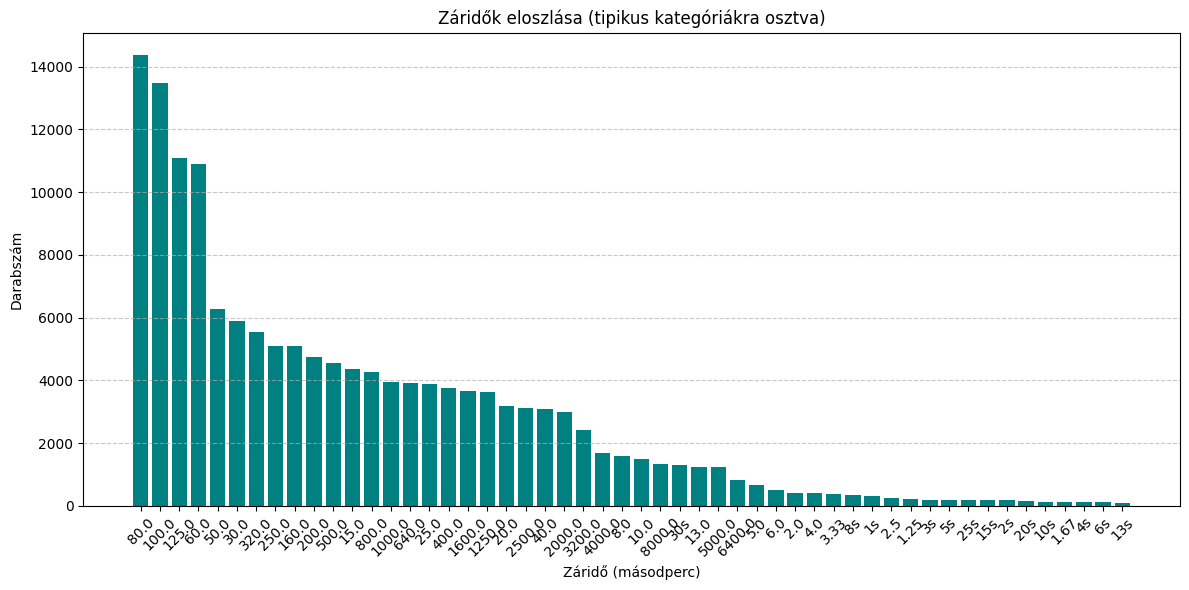

In [15]:
# Záridő kategóriák definíciója
shutter_speed_categories = [1/8000, 1/6400, 1/5000, 1/4000, 1/3200, 1/2500, 1/2000, 1/1600,
                            1/1250, 1/1000, 1/800, 1/640, 1/500, 1/400, 1/320, 1/250, 1/200,
                            1/160, 1/125, 1/100, 1/80, 1/60, 1/50, 1/40, 1/30, 1/25, 1/20,
                            1/15, 1/13, 1/10, 1/8, 1/6, 1/5, 1/4, 0.3, 0.4, 0.5, 0.6, 0.8,
                            1, 1.3, 1.6, 2, 2.5, 3.2, 4, 5, 6, 8, 10, 13, 15, 20, 25, 30]

# CSV beolvasás
shutter_df = pd.read_csv("EXIF_ZARIDO.csv")
shutter_df['Záridő'] = pd.to_numeric(shutter_df['Záridő'], errors='coerce')
shutter_df['Darabszám'] = pd.to_numeric(shutter_df['Darabszám'], errors='coerce')
shutter_df = shutter_df.dropna()

# Legközelebbi kategória hozzárendelése
def closest_shutter(val):
    return min(shutter_speed_categories, key=lambda x: abs(x - val))

shutter_df['Záridő_kategória'] = shutter_df['Záridő'].apply(closest_shutter)

# Csoportosítás, összegzés, rendezés
grouped_shutter = shutter_df.groupby('Záridő_kategória')['Darabszám'].sum().reset_index()
grouped_shutter = grouped_shutter.sort_values('Darabszám', ascending=False)

# Eredmény kiírás és ábrázolás
print(grouped_shutter)

plt.figure(figsize=(12, 6))
plt.bar([str(round(1/s, 2)) if s < 1 else str(int(s))+"s" for s in grouped_shutter['Záridő_kategória']],
        grouped_shutter['Darabszám'], color='teal')
plt.title('Záridők eloszlása (tipikus kategóriákra osztva)')
plt.xlabel('Záridő (másodperc)')
plt.ylabel('Darabszám')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


   Záridő (formázva)  Darabszám
20             1/80s      14364
19            1/100s      13498
18            1/125s      11103
21             1/60s      10894
22             1/50s       6286
24             1/30s       5880
14            1/320s       5534
15            1/250s       5089
17            1/160s       5085
16            1/200s       4759
12            1/500s       4560
27             1/15s       4372
10            1/800s       4255
9            1/1000s       3934
11            1/640s       3915
25             1/25s       3881
13            1/400s       3769
7            1/1600s       3669
8            1/1250s       3642
26             1/20s       3173
5            1/2500s       3111
23             1/40s       3073
6            1/2000s       2993
4            1/3200s       2405
3            1/4000s       1681
30              1/8s       1583
29             1/10s       1481
0            1/8000s       1346
54             30.0s       1314
28             1/13s       1251
2       

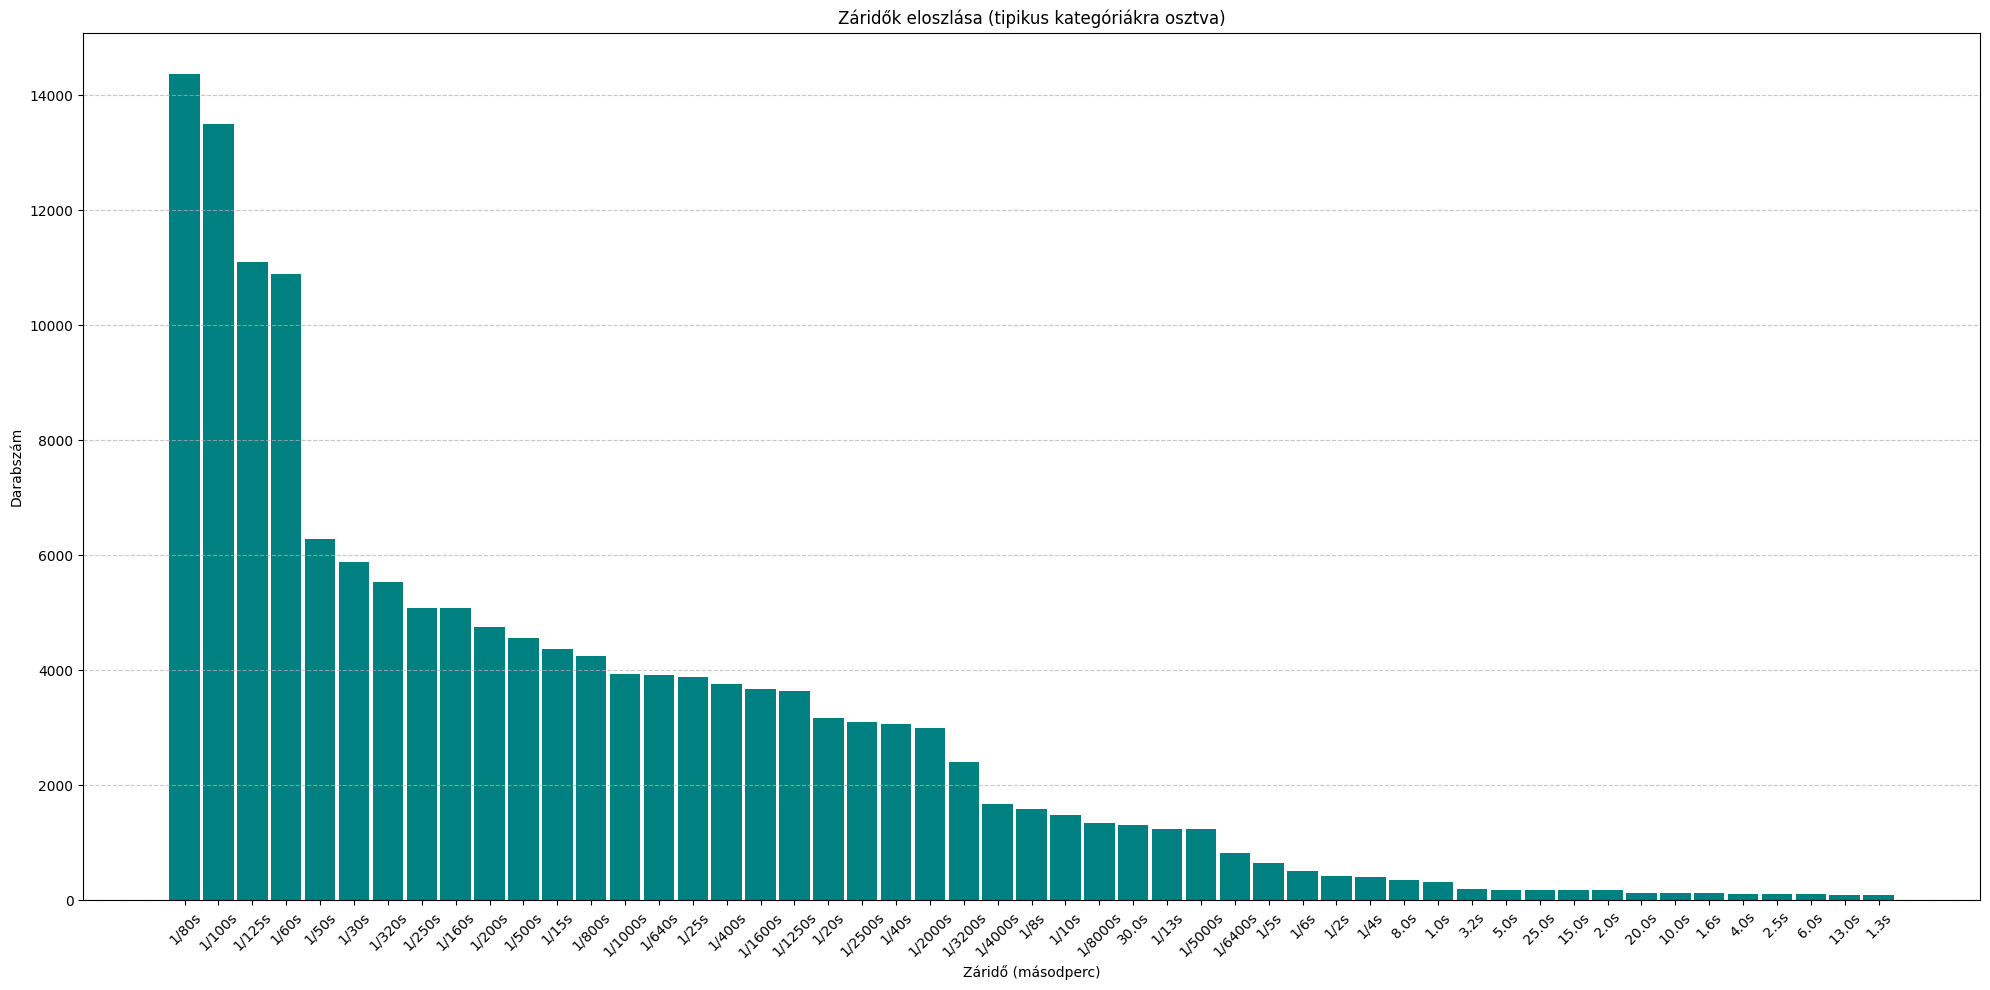

In [19]:
from fractions import Fraction

# Segédfüggvény a hagyományos megjelenítéshez
def format_shutter_label(value):
    if value < 1:
        frac = Fraction(value).limit_denominator(10000)  # pl. 0.0125 -> 1/80
        return f"1/{frac.denominator}s"
    else:
        return f"{round(value, 1)}s"

# Záridő kategóriák definíciója
shutter_speed_categories = [1/8000, 1/6400, 1/5000, 1/4000, 1/3200, 1/2500, 1/2000, 1/1600,
                            1/1250, 1/1000, 1/800, 1/640, 1/500, 1/400, 1/320, 1/250, 1/200,
                            1/160, 1/125, 1/100, 1/80, 1/60, 1/50, 1/40, 1/30, 1/25, 1/20,
                            1/15, 1/13, 1/10, 1/8, 1/6, 1/5, 1/4, 0.3, 0.4, 0.5, 0.6, 0.8,
                            1, 1.3, 1.6, 2, 2.5, 3.2, 4, 5, 6, 8, 10, 13, 15, 20, 25, 30]

# CSV beolvasás
shutter_df = pd.read_csv("EXIF_ZARIDO.csv")
shutter_df['Záridő'] = pd.to_numeric(shutter_df['Záridő'], errors='coerce')
shutter_df['Darabszám'] = pd.to_numeric(shutter_df['Darabszám'], errors='coerce')
shutter_df = shutter_df.dropna()

# Legközelebbi kategória hozzárendelése
def closest_shutter(val):
    return min(shutter_speed_categories, key=lambda x: abs(x - val))

shutter_df['Záridő_kategória'] = shutter_df['Záridő'].apply(closest_shutter)

# Csoportosítás, összegzés, rendezés
grouped_shutter = shutter_df.groupby('Záridő_kategória')['Darabszám'].sum().reset_index()
grouped_shutter = grouped_shutter.sort_values('Darabszám', ascending=False)

# Eredmény kiírás és ábrázolás
grouped_shutter['Záridő (formázva)'] = grouped_shutter['Záridő_kategória'].apply(format_shutter_label)
print(grouped_shutter[['Záridő (formázva)', 'Darabszám']])

plt.figure(figsize=(20, 10))
plt.bar(
    [format_shutter_label(s) for s in grouped_shutter['Záridő_kategória']],
    grouped_shutter['Darabszám'],
    color='teal', width=0.9
)
plt.title('Záridők eloszlása (tipikus kategóriákra osztva)')
plt.xlabel('Záridő (másodperc)')
plt.ylabel('Darabszám')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

   Blende (formázva)  Darabszám
6              f 4.0      35530
7              f 5.6      34615
2              f 1.8      23228
4              f 2.8      20213
5              f 3.5      18187
3              f 2.0       7790
9             f 11.0       3886
8              f 8.0       2644
0              f 1.2       2234
11            f 22.0        611
10            f 16.0        244
1              f 1.4          1


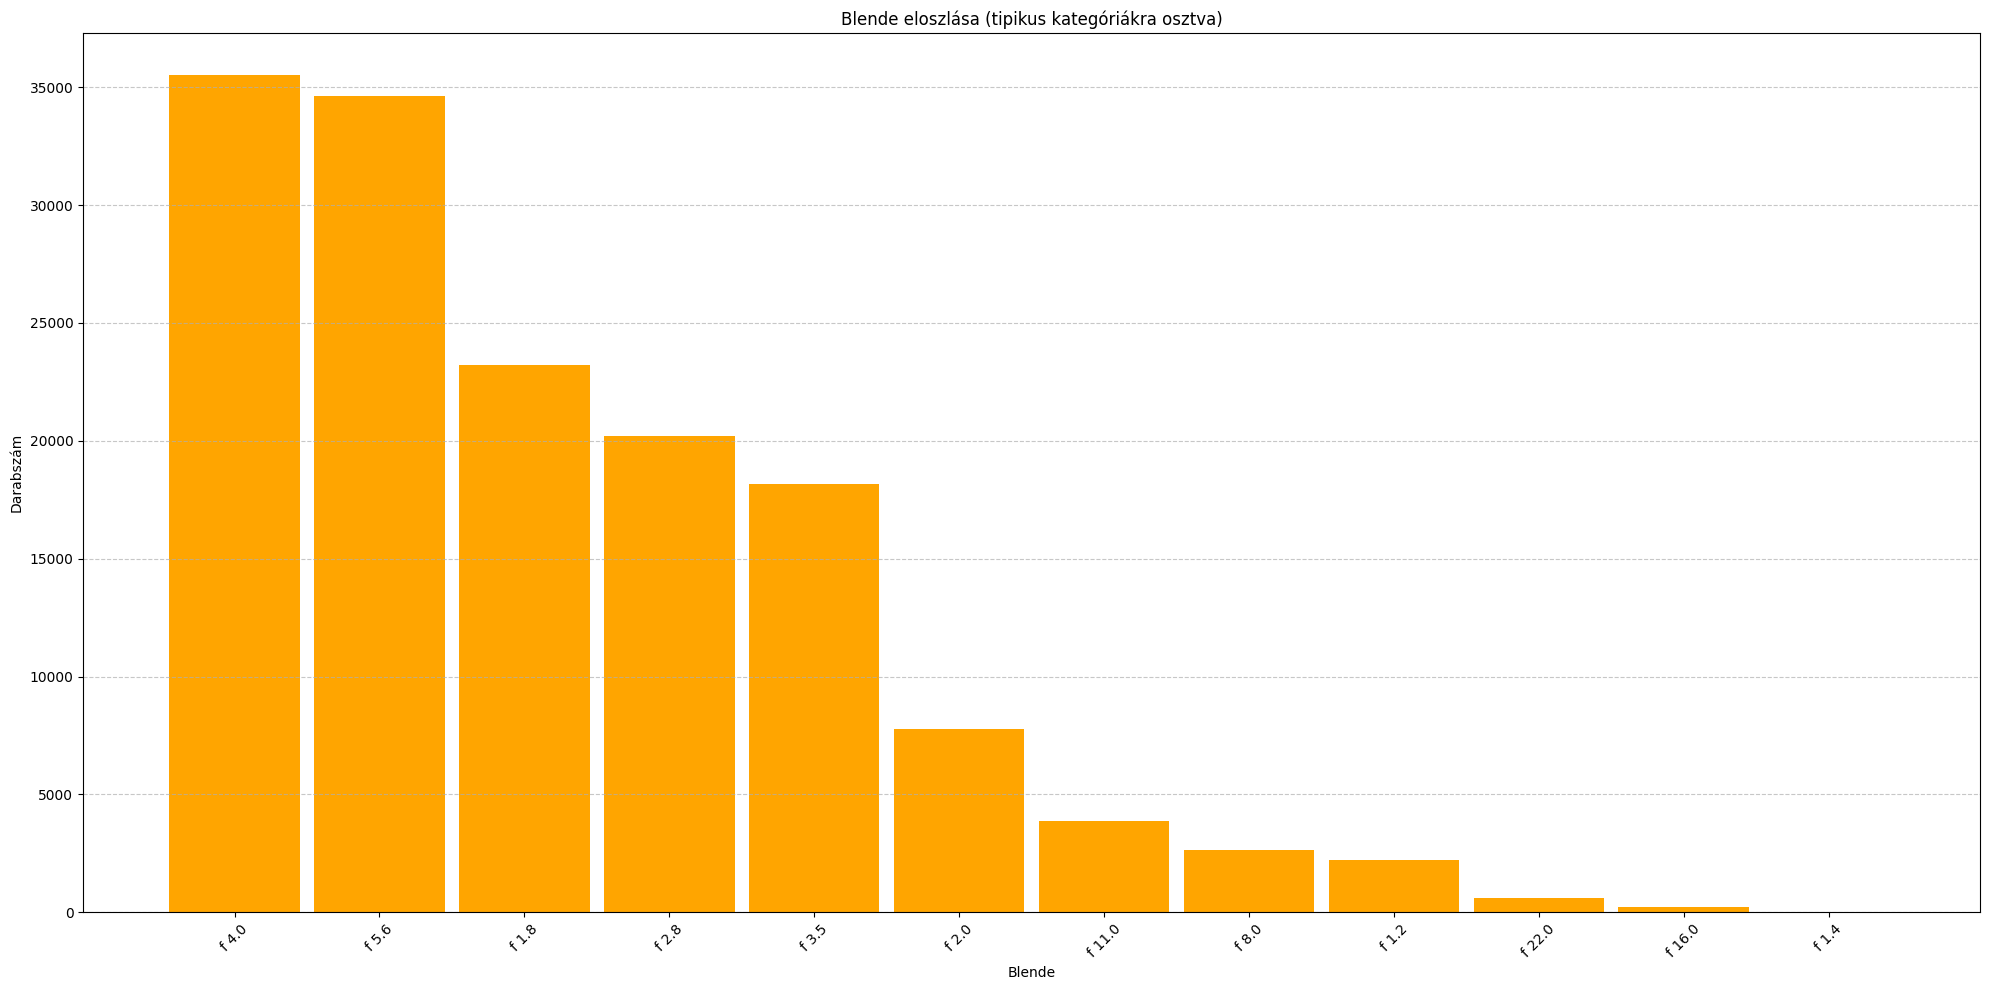

In [30]:
from fractions import Fraction

# Segédfüggvény a hagyományos megjelenítéshez
def format_shutter_label(value):
    if value < 1:
        frac = Fraction(value).limit_denominator(10000)  # pl. 0.0125 -> 1/80
        return f"f {frac.denominator}"
    else:
        return f"f {round(value, 1)}"

# Záridő kategóriák definíciója
blende_speed_categories = [1.2,1.4,1.8,2.0,2.8,3.5,4.0,5.6,8.0,11,16,22]

# CSV beolvasás
shutter_df = pd.read_csv("EXIF_BLENDE.csv")
shutter_df['Blende'] = pd.to_numeric(shutter_df['Blende'], errors='coerce')
shutter_df['Darabszám'] = pd.to_numeric(shutter_df['Darabszám'], errors='coerce')
shutter_df = shutter_df.dropna()

# Legközelebbi kategória hozzárendelése
def closest_shutter(val):
    return min(blende_speed_categories, key=lambda x: abs(x - val))

shutter_df['Blende_kategória'] = shutter_df['Blende'].apply(closest_shutter)

# Csoportosítás, összegzés, rendezés
grouped_shutter = shutter_df.groupby('Blende_kategória')['Darabszám'].sum().reset_index()
grouped_shutter = grouped_shutter.sort_values('Darabszám', ascending=False)

# Eredmény kiírás és ábrázolás
grouped_shutter['Blende (formázva)'] = grouped_shutter['Blende_kategória'].apply(format_shutter_label)
print(grouped_shutter[['Blende (formázva)', 'Darabszám']])

plt.figure(figsize=(20, 10))
plt.bar(
    [format_shutter_label(s) for s in grouped_shutter['Blende_kategória']],
    grouped_shutter['Darabszám'],
    color='orange', width=0.9
)
plt.title('Blende eloszlása (tipikus kategóriákra osztva)')
plt.xlabel('Blende')
plt.ylabel('Darabszám')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

   Fókusztáv  Darabszám
0       4 mm      34477
3      18 mm      26833
6      35 mm      18254
1       6 mm      11206
27    300 mm      10182
13     70 mm       6007
5      24 mm       4962
23    200 mm       4581
2      14 mm       4053
22    155 mm       3387
10     55 mm       3153
21    135 mm       3044
18    105 mm       2244
7      40 mm       1861
4      22 mm       1800
14     75 mm       1765
15     80 mm       1690
17    100 mm       1521
8      45 mm       1466
9      50 mm       1267
20    130 mm       1190
16     85 mm       1187
19    120 mm       1122
24    240 mm        654
25    250 mm        623
26    270 mm        491
12     65 mm        299
11     60 mm        127


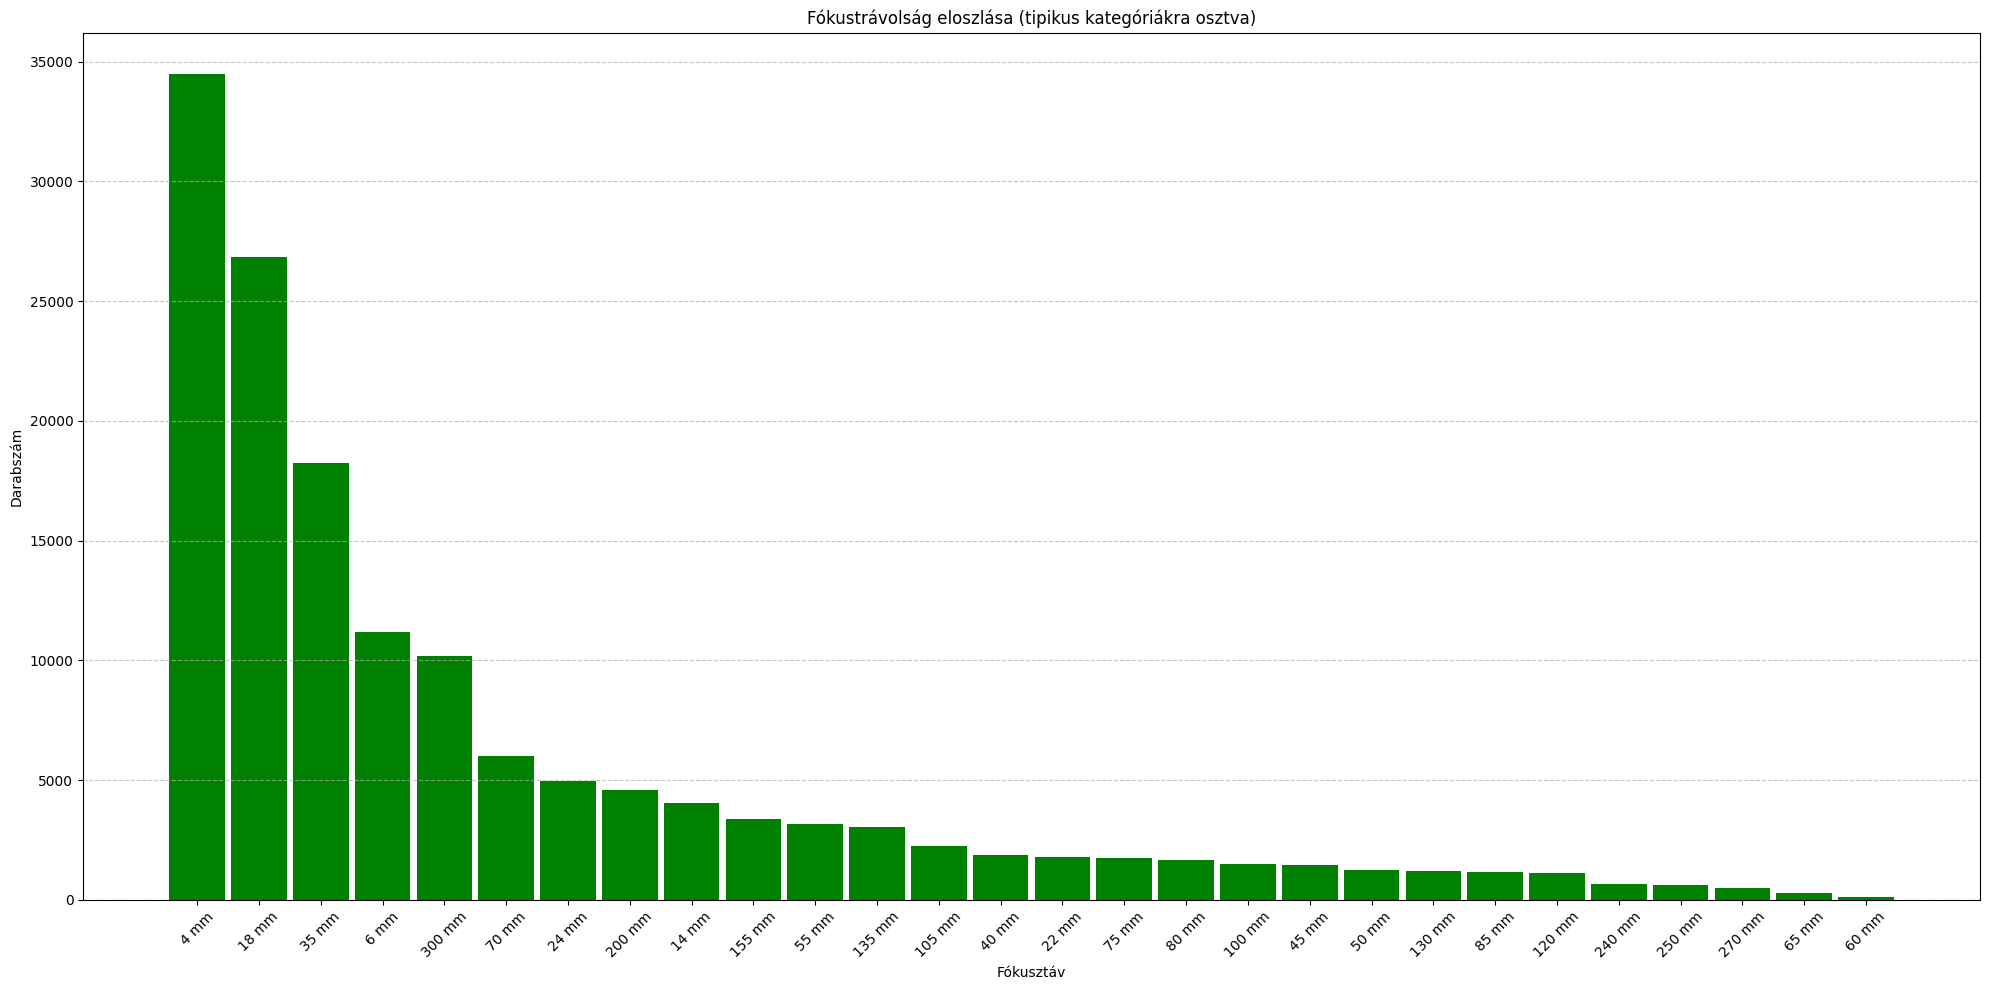

In [31]:
from fractions import Fraction

# Segédfüggvény a hagyományos megjelenítéshez
def format_shutter_label(value):
    if value < 1:
        frac = Fraction(value).limit_denominator(10000)  # pl. 0.0125 -> 1/80
        return f"{frac.denominator} mm"
    else:
        return f"{round(value, 1)} mm"

# Záridő kategóriák definíciója
focal_length_speed_categories = [
    4, 6, 14, 18, 22, 24, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80,
    85, 100, 105, 155, 120, 130, 135, 200, 240, 250, 270, 300, 350, 400
]

# CSV beolvasás
shutter_df = pd.read_csv("EXIF_MM.csv")
shutter_df['Fókusztáv'] = pd.to_numeric(shutter_df['Fókusztáv'], errors='coerce')
shutter_df['Darabszám'] = pd.to_numeric(shutter_df['Darabszám'], errors='coerce')
shutter_df = shutter_df.dropna()

# Legközelebbi kategória hozzárendelése
def closest_shutter(val):
    return min(focal_length_speed_categories, key=lambda x: abs(x - val))

shutter_df['Fókusztáv_kategória'] = shutter_df['Fókusztáv'].apply(closest_shutter)

# Csoportosítás, összegzés, rendezés
grouped_shutter = shutter_df.groupby('Fókusztáv_kategória')['Darabszám'].sum().reset_index()
grouped_shutter = grouped_shutter.sort_values('Darabszám', ascending=False)

# Eredmény kiírás és ábrázolás
grouped_shutter['Fókusztáv'] = grouped_shutter['Fókusztáv_kategória'].apply(format_shutter_label)
print(grouped_shutter[['Fókusztáv', 'Darabszám']])

plt.figure(figsize=(20, 10))
plt.bar(
    [format_shutter_label(s) for s in grouped_shutter['Fókusztáv_kategória']],
    grouped_shutter['Darabszám'],
    color='green', width=0.9
)
plt.title('Fókustrávolság eloszlása (tipikus kategóriákra osztva)')
plt.xlabel('Fókusztáv')
plt.ylabel('Darabszám')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [35]:
import pandas as pd

# Expozíciós módok és darabszámok
expozicios_modok = {
    "Expozíciós mód": [1, 3, 0, 2, 4, 6, 7, 8, 5],
    "Darabszám": [53745, 42061, 35055, 16695, 662, 333, 151, 124, 31]
}

# Expozíciós mód jelentések
jelentesek = {
    "Expozíciós mód": [0, 1, 2, 3, 4, 5, 6, 7, 8],
    "Jelentés": ["Nincs meghatározva", "Manuális", "Program", "Rekeszprioritásos",
                 "Zárprioritásos", "Kreatív mód", "Akció mód", "Portré mód", "Táj mód"],
    "Jelentés angolul": ["Not defined", "Manual", "Program", "Aperture-priority",
                         "Shutter-priority", "Creative", "Action", "Portrait", "Landscape"],
    "Rövidítés": ["NA", "M", "P", "A", "S", "CR", "AC", "PR", "LS"]
}

# Táblázatok létrehozása
df_darabszam = pd.DataFrame(expozicios_modok)
df_jelentes = pd.DataFrame(jelentesek)

# Csatlakoztatjuk a két táblázatot
df = pd.merge(df_darabszam, df_jelentes, on="Expozíciós mód")

# Rendezzük darabszám szerint csökkenő sorrendbe
df_sorted = df.sort_values(by="Darabszám", ascending=False)

# Megjelenítjük a táblázatot
print(df_sorted[["Expozíciós mód", "Darabszám", "Jelentés", "Rövidítés"]])


   Expozíciós mód  Darabszám            Jelentés Rövidítés
0               1      53745            Manuális         M
1               3      42061   Rekeszprioritásos         A
2               0      35055  Nincs meghatározva        NA
3               2      16695             Program         P
4               4        662      Zárprioritásos         S
5               6        333           Akció mód        AC
6               7        151          Portré mód        PR
7               8        124             Táj mód        LS
8               5         31         Kreatív mód        CR


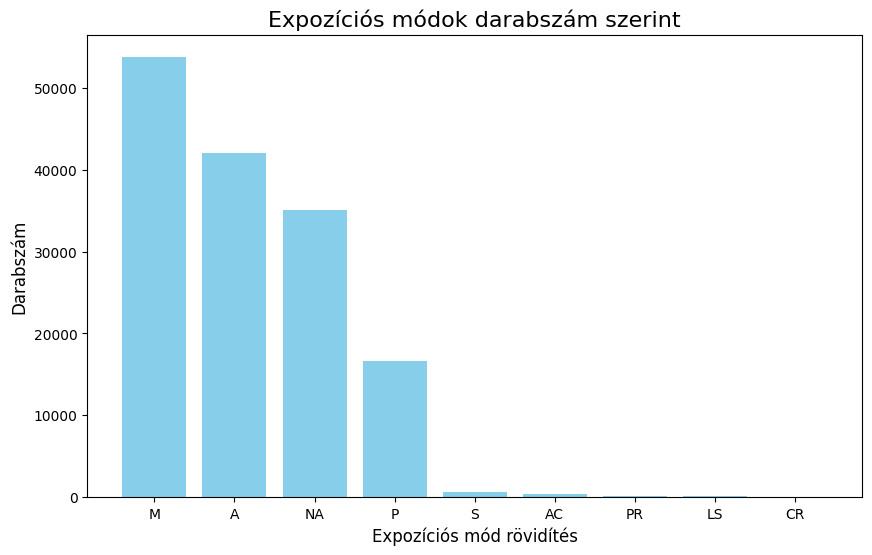

In [36]:
import matplotlib.pyplot as plt

# Grafikon készítése
plt.figure(figsize=(10, 6))
plt.bar(df_sorted["Rövidítés"], df_sorted["Darabszám"], color="skyblue")

# Címek és feliratok hozzáadása
plt.title("Expozíciós módok darabszám szerint", fontsize=16)
plt.xlabel("Expozíciós mód rövidítés", fontsize=12)
plt.ylabel("Darabszám", fontsize=12)

# Ábra megjelenítése
plt.show()


   Fénymérés  Darabszám          Jelentés Rövidítés
0          5      94535             Minta         P
1          2      45285  Középponti átlag         C
2          3       7357              Spot         S
3          1       1863           Átlagos         A
4          4        175   Többszörös spot         M
5          0         29        Ismeretlen         U


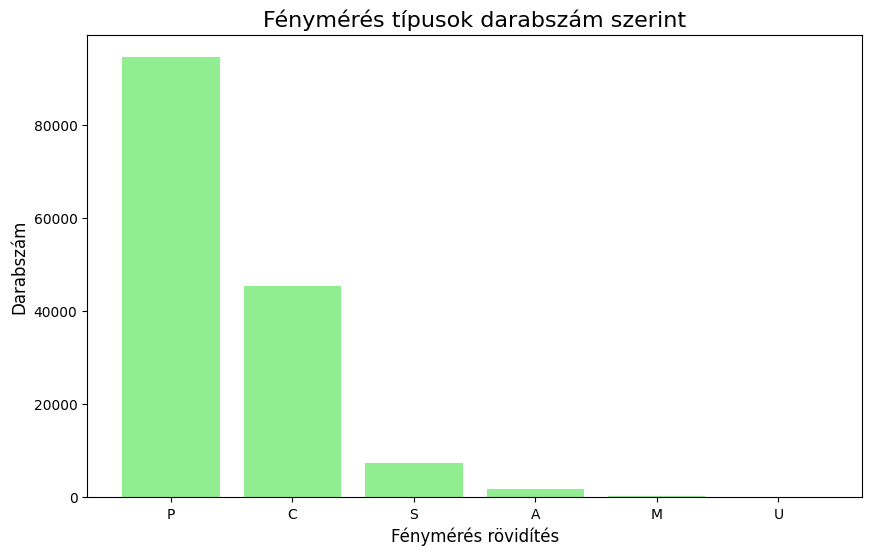

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Fénymérés darabszám adatok
fenymeres_darabszam = {
    "Fénymérés": [5, 2, 3, 1, 4, 0],
    "Darabszám": [94535, 45285, 7357, 1863, 175, 29]
}

# Fénymérés jelentések
fenymeres_jelentesek = {
    "Fénymérés": [0, 1, 2, 3, 4, 5, 6],
    "Jelentés": ["Ismeretlen", "Átlagos", "Középponti átlag", "Spot", "Többszörös spot", "Minta", "Részleges"],
    "Jelentés angolul": ["Unknown", "Average", "Center-weighted-average", "Spot", "Multi-spot", "Pattern", "Partial"],
    "Rövidítés": ["U", "A", "C", "S", "M", "P", "PA"]
}

# Táblázatok létrehozása
df_darabszam = pd.DataFrame(fenymeres_darabszam)
df_jelentes = pd.DataFrame(fenymeres_jelentesek)

# Csatlakoztatjuk a két táblázatot
df = pd.merge(df_darabszam, df_jelentes, on="Fénymérés")

# Rendezzük darabszám szerint csökkenő sorrendbe
df_sorted = df.sort_values(by="Darabszám", ascending=False)

# Táblázat megjelenítése
print(df_sorted[["Fénymérés", "Darabszám", "Jelentés", "Rövidítés"]])

# Grafikon készítése
plt.figure(figsize=(10, 6))
plt.bar(df_sorted["Rövidítés"], df_sorted["Darabszám"], color="lightgreen")

# Címek és feliratok
plt.title("Fénymérés típusok darabszám szerint", fontsize=16)
plt.xlabel("Fénymérés rövidítés", fontsize=12)
plt.ylabel("Darabszám", fontsize=12)

# Ábra megjelenítése
plt.show()


    Vaku  Darabszám                                         Jelentés Rövidítés
0      0      85559                                  A vaku nem lőtt         N
1     16      45188          Kényszerített üzem , de a vaku nem lőtt        NM
2      9       4717            Kényszerített manuális üzem vaku lőtt        YM
3     25       2625                        Automatikus mód vaku lőtt        NA
4      7       2571      A vaku lőtt és a visszatérő fényt észlelték       YYR
5      5       2370  A vaku lőtt de a visszatérő fényt nem észlelték       YNR
6     89       1324                                       Ismeretlen         ?
7     15        969                                       Ismeretlen         ?
8     29        942                                       Ismeretlen         ?
9      1        791                                      A vaku lőtt         Y
10    24        727                    Automatikus mód vaku nem lőtt        YA
11    69        575                                 

<ipython-input-38-f2084992b998>:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Jelentés"].fillna("Ismeretlen", inplace=True)
<ipython-input-38-f2084992b998>:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

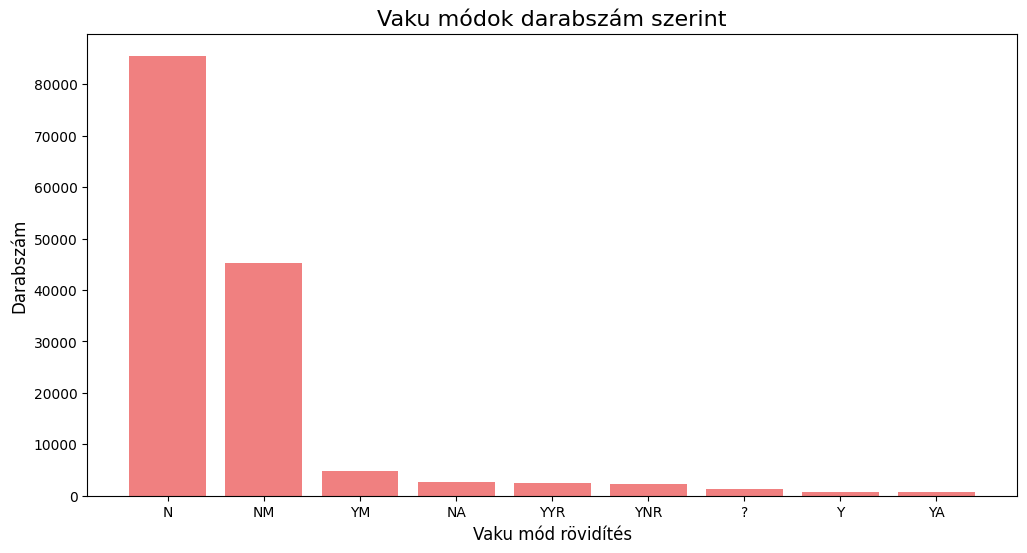

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Vaku mód darabszámok
vaku_darabszam = {
    "Vaku": [0, 16, 9, 25, 7, 5, 89, 15, 29, 1, 24, 69, 93, 4, 95, 71, 73, 88, 13, 32, 31, 79, 17],
    "Darabszám": [85559, 45188, 4717, 2625, 2571, 2370, 1324, 969, 942, 791, 727, 575, 226, 117, 87, 79, 75, 70, 15, 12, 8, 6, 1]
}

# Vaku mód jelentések
vaku_jelentesek = {
    "Vaku": [0, 1, 5, 7, 9, 16, 24, 25],
    "Jelentés": [
        "A vaku nem lőtt",
        "A vaku lőtt",
        "A vaku lőtt de a visszatérő fényt nem észlelték",
        "A vaku lőtt és a visszatérő fényt észlelték",
        "Kényszerített manuális üzem vaku lőtt",
        "Kényszerített üzem , de a vaku nem lőtt",
        "Automatikus mód vaku nem lőtt",
        "Automatikus mód vaku lőtt"
    ],
    "Jelentés angolul": [
        "Flash did not fire",
        "Flash fired",
        "Strobe return not detected",
        "Strobe return detected",
        "Compulsory",
        "Compulsory mode",
        "Automatic",
        "Automatic"
    ],
    "Rövidítés": ["N", "Y", "YNR", "YYR", "YM", "NM", "YA", "NA"]
}

# Táblázatok létrehozása
df_darabszam = pd.DataFrame(vaku_darabszam)
df_jelentes = pd.DataFrame(vaku_jelentesek)

# Csatlakoztatás bal oldali illesztéssel, hogy minden darabszám szerepeljen
df = pd.merge(df_darabszam, df_jelentes, on="Vaku", how="left")

# Hiányzó jelentések kitöltése
df["Jelentés"].fillna("Ismeretlen", inplace=True)
df["Rövidítés"].fillna("?", inplace=True)

# Rendezzük darabszám szerint csökkenő sorrendbe
df_sorted = df.sort_values(by="Darabszám", ascending=False)

# Táblázat megjelenítése
print(df_sorted[["Vaku", "Darabszám", "Jelentés", "Rövidítés"]])

# Grafikon készítése (csak rövidítések)
plt.figure(figsize=(12, 6))
plt.bar(df_sorted["Rövidítés"], df_sorted["Darabszám"], color="lightcoral")

# Címek és feliratok
plt.title("Vaku módok darabszám szerint", fontsize=16)
plt.xlabel("Vaku mód rövidítés", fontsize=12)
plt.ylabel("Darabszám", fontsize=12)

# Ábra megjelenítése
plt.show()


   Vaku  Darabszám                                         Jelentés Rövidítés
0     0      85559                                  A vaku nem lőtt         N
1    16      45188          Kényszerített üzem , de a vaku nem lőtt        NM
2     9       4717            Kényszerített manuális üzem vaku lőtt        YM
8    -1       4506                                            Egyéb         E
3    25       2625                        Automatikus mód vaku lőtt        NA
4     7       2571      A vaku lőtt és a visszatérő fényt észlelték       YYR
5     5       2370  A vaku lőtt de a visszatérő fényt nem észlelték       YNR
6     1        791                                      A vaku lőtt         Y
7    24        727                    Automatikus mód vaku nem lőtt        YA


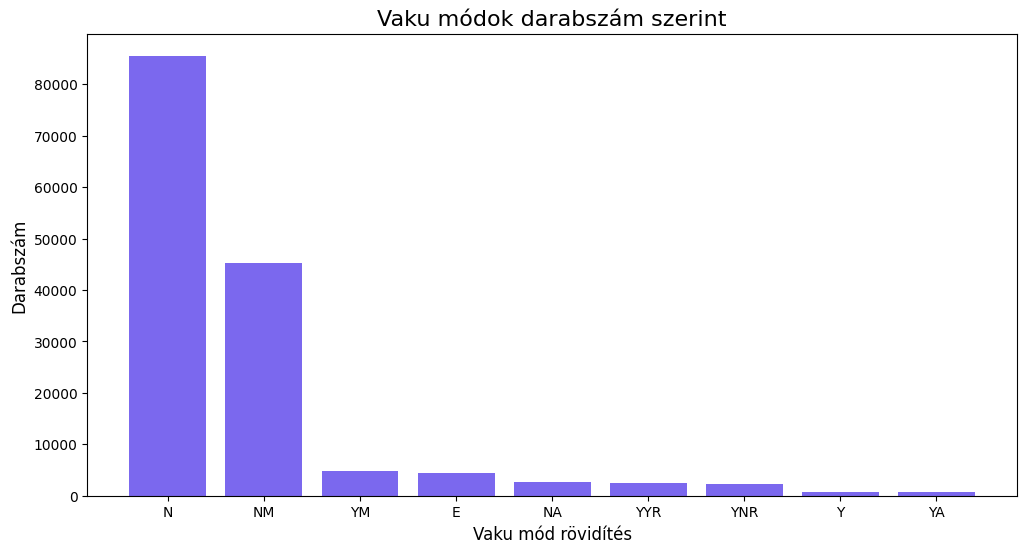

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Vaku darabszám adatok
vaku_darabszam = {
    "Vaku": [0, 16, 9, 25, 7, 5, 89, 15, 29, 1, 24, 69, 93, 4, 95, 71, 73, 88, 13, 32, 31, 79, 17],
    "Darabszám": [85559, 45188, 4717, 2625, 2571, 2370, 1324, 969, 942, 791, 727, 575, 226, 117, 87, 79, 75, 70, 15, 12, 8, 6, 1]
}

# Ismert vaku módok jelentése
vaku_jelentesek = {
    "Vaku": [0, 1, 5, 7, 9, 16, 24, 25],
    "Jelentés": [
        "A vaku nem lőtt",
        "A vaku lőtt",
        "A vaku lőtt de a visszatérő fényt nem észlelték",
        "A vaku lőtt és a visszatérő fényt észlelték",
        "Kényszerített manuális üzem vaku lőtt",
        "Kényszerített üzem , de a vaku nem lőtt",
        "Automatikus mód vaku nem lőtt",
        "Automatikus mód vaku lőtt"
    ],
    "Jelentés angolul": [
        "Flash did not fire",
        "Flash fired",
        "Strobe return not detected",
        "Strobe return detected",
        "Compulsory",
        "Compulsory mode",
        "Automatic",
        "Automatic"
    ],
    "Rövidítés": ["N", "Y", "YNR", "YYR", "YM", "NM", "YA", "NA"]
}

# Táblázatok létrehozása
df_darabszam = pd.DataFrame(vaku_darabszam)
df_jelentes = pd.DataFrame(vaku_jelentesek)

# Csatlakoztatás bal oldali illesztéssel
df = pd.merge(df_darabszam, df_jelentes, on="Vaku", how="left")

# Szétválasztjuk az ismert és ismeretlen sorokat
df_ismertek = df[df["Jelentés"].notna()]
df_ismeretlenek = df[df["Jelentés"].isna()]

# Összesítjük az ismeretlen sorokat „Egyéb” kategóriába
egyeb_osszeg = df_ismeretlenek["Darabszám"].sum()

# Új sor „Egyéb” néven
df_egyeb = pd.DataFrame([{
    "Vaku": -1,  # Nincs jelentése, csak logikai azonosító
    "Darabszám": egyeb_osszeg,
    "Jelentés": "Egyéb",
    "Jelentés angolul": "Other",
    "Rövidítés": "E"
}])

# Összefűzzük a táblázatokat
df_final = pd.concat([df_ismertek, df_egyeb], ignore_index=True)

# Rendezés darabszám szerint
df_sorted = df_final.sort_values(by="Darabszám", ascending=False)

# Táblázat megjelenítése
print(df_sorted[["Vaku", "Darabszám", "Jelentés", "Rövidítés"]])

# Grafikon készítése
plt.figure(figsize=(12, 6))
plt.bar(df_sorted["Rövidítés"], df_sorted["Darabszám"], color="mediumslateblue")

# Címek és feliratok
plt.title("Vaku módok darabszám szerint", fontsize=16)
plt.xlabel("Vaku mód rövidítés", fontsize=12)
plt.ylabel("Darabszám", fontsize=12)

# Ábra megjelenítése
plt.show()


   Fehéregyensúly  Darabszám                    Jelentés Rövidítés
0               0     132902  Automatikus fehéregyensúly         A
1               1      14357     Manuális fehéregyensúly         M


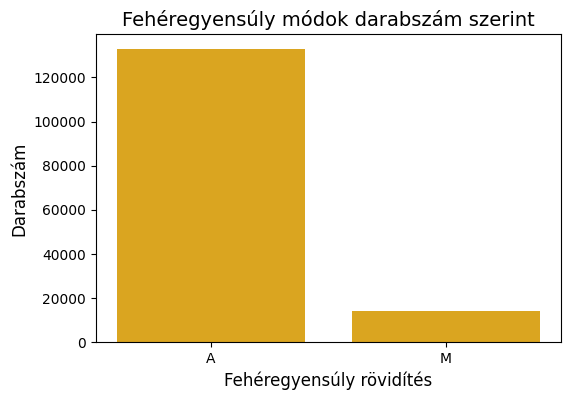

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Fehéregyensúly darabszámok
feher_darabszam = {
    "Fehéregyensúly": [0, 1],
    "Darabszám": [132902, 14357]
}

# Fehéregyensúly jelentések
feher_jelentesek = {
    "Fehéregyensúly": [0, 1],
    "Jelentés": ["Automatikus fehéregyensúly", "Manuális fehéregyensúly"],
    "Jelentés angolul": ["Automatic", "Manual"],
    "Rövidítés": ["A", "M"]
}

# Adatok DataFrame-be
df_darabszam = pd.DataFrame(feher_darabszam)
df_jelentes = pd.DataFrame(feher_jelentesek)

# Összekapcsolás
df = pd.merge(df_darabszam, df_jelentes, on="Fehéregyensúly")

# Rendezzük darabszám szerint
df_sorted = df.sort_values(by="Darabszám", ascending=False)

# Táblázat megjelenítése
print(df_sorted[["Fehéregyensúly", "Darabszám", "Jelentés", "Rövidítés"]])

# Grafikon készítése
plt.figure(figsize=(6, 4))
plt.bar(df_sorted["Rövidítés"], df_sorted["Darabszám"], color="goldenrod")

# Címek
plt.title("Fehéregyensúly módok darabszám szerint", fontsize=14)
plt.xlabel("Fehéregyensúly rövidítés", fontsize=12)
plt.ylabel("Darabszám", fontsize=12)

# Megjelenítés
plt.show()


Összes kép: 180750
   EXIF  Darabszám        Jelentés Rövidítés
1     1     164149  Olvasható EXIF  Existing
0     0      16601    Hiányzó EXIF   Missing


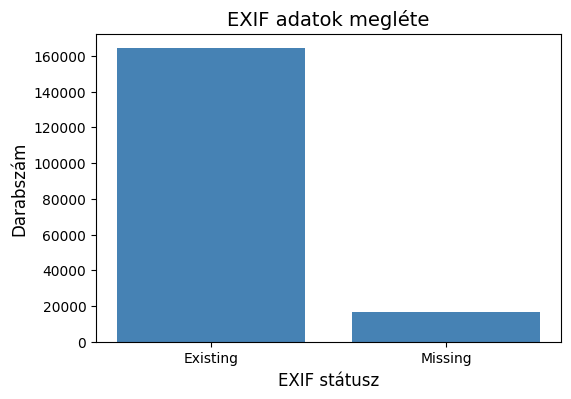

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# EXIF darabszám adatok
exif_darabszam = {
    "EXIF": [0, 1],
    "Darabszám": [16601, 164149]
}

# EXIF jelentések
exif_jelentesek = {
    "EXIF": [0, 1],
    "Jelentés": ["Hiányzó EXIF", "Olvasható EXIF"],
    "Jelentés angolul": ["missing EXIF", "existing EXIF"],
    "Rövidítés": ["Missing", "Existing"]
}

# DataFrame-ek létrehozása
df_darabszam = pd.DataFrame(exif_darabszam)
df_jelentes = pd.DataFrame(exif_jelentesek)

# Összefűzés
df = pd.merge(df_darabszam, df_jelentes, on="EXIF")

# Rendezzük darabszám szerint csökkenő sorrendbe
df_sorted = df.sort_values(by="Darabszám", ascending=False)

# Táblázat megjelenítése
print("Összes kép: 180750")
print(df_sorted[["EXIF", "Darabszám", "Jelentés", "Rövidítés"]])

# Grafikon készítése
plt.figure(figsize=(6, 4))
plt.bar(df_sorted["Rövidítés"], df_sorted["Darabszám"], color="steelblue")

# Címek
plt.title("EXIF adatok megléte", fontsize=14)
plt.xlabel("EXIF státusz", fontsize=12)
plt.ylabel("Darabszám", fontsize=12)

# Megjelenítés
plt.show()


      Év  Darabszám
20  2002         19
21  2004          2
19  2006        174
17  2007       1098
16  2008       2291
1   2009      14713
18  2010       2530
3   2011      12632
12  2012       5745
5   2013      10602
8   2014       8155
7   2015       9162
10  2016       7425
6   2017      10196
11  2018       6334
14  2019       2836
13  2020       4013
9   2021       7788
4   2022      12477
2   2023      14551
0   2024      16768
15  2025       2608


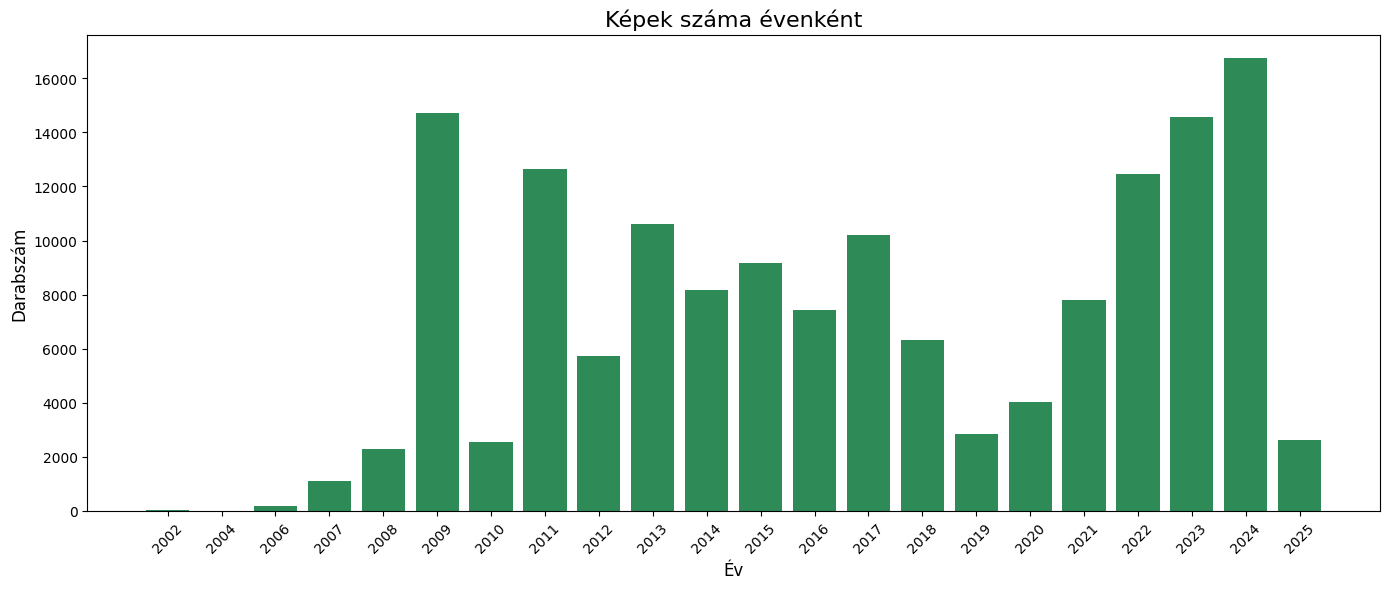

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Adatok beolvasása
ev_darabszam = {
    "Év": [
        2024, 2009, 2023, 2011, 2022, 2013, 2017, 2015,
        2014, 2021, 2016, 2018, 2012, 2020, 2019, 2025,
        2008, 2007, 2010, 2006, 2002, 2004
    ],
    "Darabszám": [
        16768, 14713, 14551, 12632, 12477, 10602, 10196, 9162,
        8155, 7788, 7425, 6334, 5745, 4013, 2836, 2608,
        2291, 1098, 2530, 174, 19, 2
    ]
}

# DataFrame létrehozása
df_ev = pd.DataFrame(ev_darabszam)

# Rendezzük év szerint növekvő sorrendbe
df_ev_sorted = df_ev.sort_values(by="Év")

# Táblázat kiírása
print(df_ev_sorted)

# Oszlopdiagram (bar chart)
plt.figure(figsize=(14, 6))
plt.bar(df_ev_sorted["Év"].astype(str), df_ev_sorted["Darabszám"], color="seagreen")
plt.title("Képek száma évenként", fontsize=16)
plt.xlabel("Év", fontsize=12)
plt.ylabel("Darabszám", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


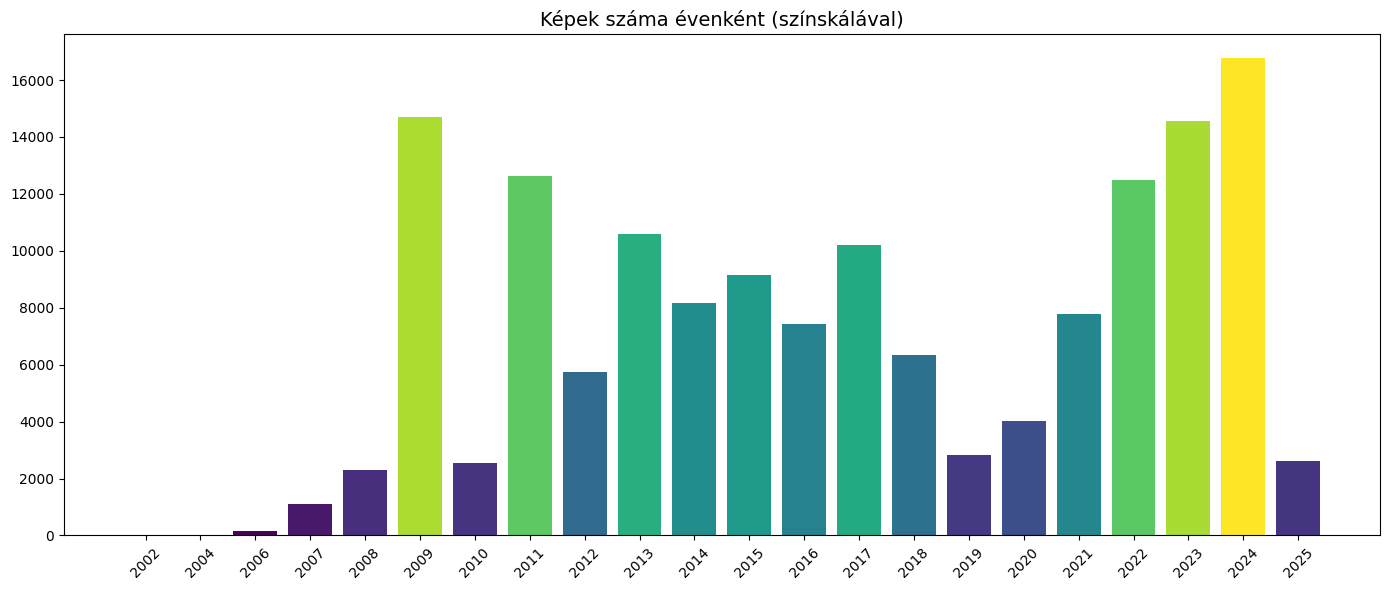

In [49]:
plt.figure(figsize=(14, 6))
plt.bar(df_ev_sorted["Év"].astype(str), df_ev_sorted["Darabszám"],
        color=plt.cm.viridis(df_ev_sorted["Darabszám"] / df_ev_sorted["Darabszám"].max()))
plt.title("Képek száma évenként (színskálával)", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
